# Rolling Statistics
- (Another) general Rule in Finance/Investing: Past performance is not an indicator for future performance.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')

In [98]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [99]:
msft=pd.read_csv(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Data\msft.csv', index_col='Date', parse_dates=['Date'])
msft

,Price,Returns
Date,,
2014-10-01,38.880157,NaN
2014-10-02,38.761566,-0.003050
2014-10-03,39.041096,0.007212
2014-10-06,39.041096,0.000000
2014-10-07,38.566757,-0.012150
...,...,...
2021-05-24,241.744537,0.022882
2021-05-25,242.650665,0.003748
2021-05-26,242.428940,-0.000914


In [100]:
msft['log_returns']=np.log(msft.Price/msft.Price.shift()) #daily Log Returns
msft

,Price,Returns,log_returns
Date,,,
2014-10-01,38.880157,NaN,NaN
2014-10-02,38.761566,-0.003050,-0.003055
2014-10-03,39.041096,0.007212,0.007186
2014-10-06,39.041096,0.000000,0.000000
2014-10-07,38.566757,-0.012150,-0.012224
...,...,...,...
2021-05-24,241.744537,0.022882,0.022624
2021-05-25,242.650665,0.003748,0.003741
2021-05-26,242.428940,-0.000914,-0.000914


In [101]:
ann_mu=msft.log_returns.mean()*252 # annualized mean return
ann_mu

np.float64(0.2741028314472096)

In [102]:
ann_std=msft.log_returns.std()*np.sqrt(252) # annualized std or returns (Alternative 1)
ann_std

np.float64(0.2735618746370175)

# Are Return and Risk constant over time? No, of course not! They change over time.
# Let´s measure/quantify this with rollings statistics!

In [103]:
window=252 # rolling window 252 days (approx. 1 year)

In [114]:
msft.log_returns.rolling(window=252)

Rolling [window=252,center=False,axis=0,method=single]

In [115]:
msft.log_returns.rolling(window=252).sum() # Alternative 1

Date
2014-10-01         NaN
2014-10-02         NaN
2014-10-03         NaN
2014-10-06         NaN
2014-10-07         NaN
                ...   
2021-05-24    0.321943
2021-05-25    0.336312
2021-05-26    0.334077
2021-05-27    0.327629
2021-05-28    0.318965
Name: log_returns, Length: 1677, dtype: float64

In [116]:
roll_mean=msft.log_returns.rolling(window=252).mean()*252
roll_mean

Date
2014-10-01         NaN
2014-10-02         NaN
2014-10-03         NaN
2014-10-06         NaN
2014-10-07         NaN
                ...   
2021-05-24    0.321943
2021-05-25    0.336312
2021-05-26    0.334077
2021-05-27    0.327629
2021-05-28    0.318965
Name: log_returns, Length: 1677, dtype: float64

In [117]:
roll_mean.iloc[250:]

Date
2015-09-29         NaN
2015-09-30         NaN
2015-10-01   -0.002078
2015-10-02    0.022269
2015-10-05    0.038078
                ...   
2021-05-24    0.321943
2021-05-25    0.336312
2021-05-26    0.334077
2021-05-27    0.327629
2021-05-28    0.318965
Name: log_returns, Length: 1427, dtype: float64

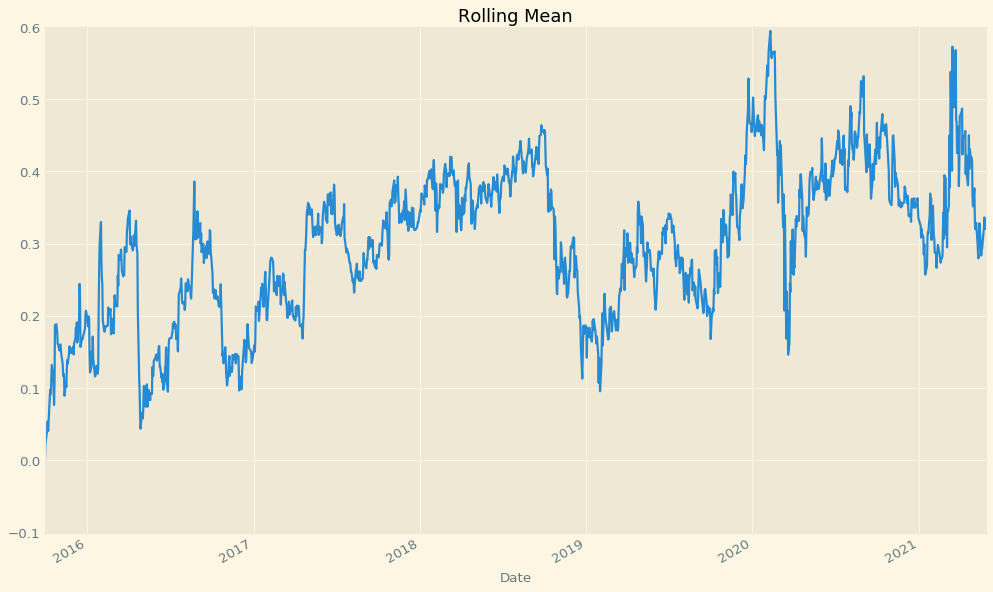

In [118]:
roll_mean.plot(figsize=(12,8))
plt.title('Rolling Mean')
plt.show()

In [119]:
roll_std=msft.log_returns.rolling(window=252).std()
roll_std

Date
2014-10-01         NaN
2014-10-02         NaN
2014-10-03         NaN
2014-10-06         NaN
2014-10-07         NaN
                ...   
2021-05-24    0.017589
2021-05-25    0.017574
2021-05-26    0.017574
2021-05-27    0.017584
2021-05-28    0.017575
Name: log_returns, Length: 1677, dtype: float64

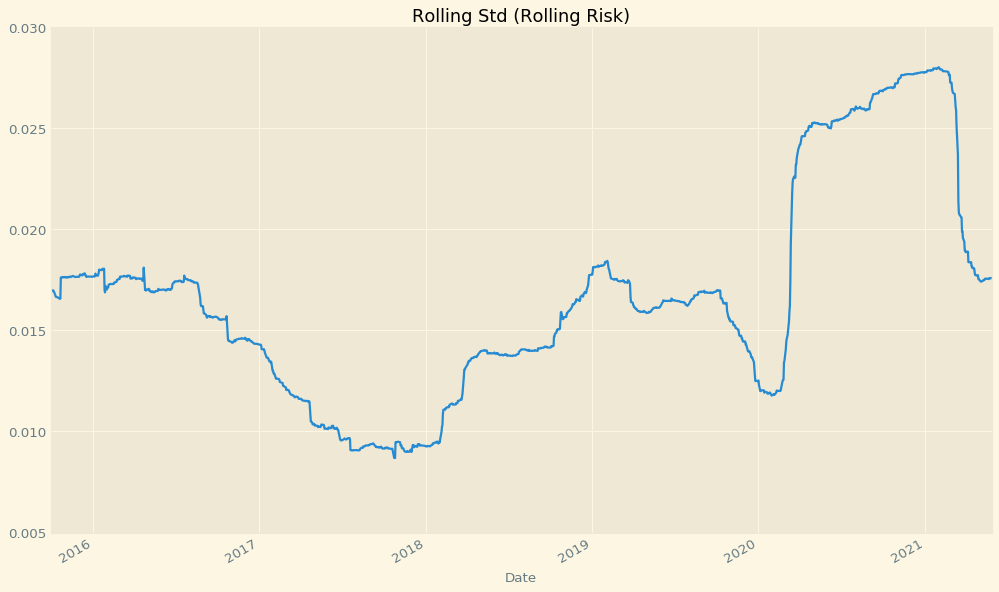

In [120]:
roll_std.plot(figsize=(12,8))
plt.title('Rolling Std (Rolling Risk)')
plt.show()

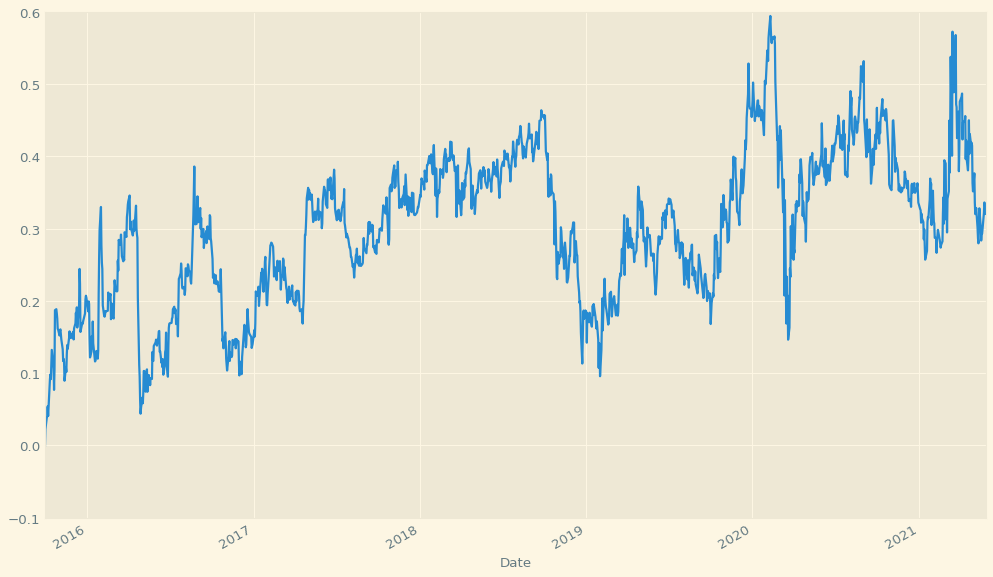

In [122]:
roll_mean.plot(figsize=(12,8))
roll_std.plot()
# plt.title('Rolling Std (Rolling Risk)')
plt.show()

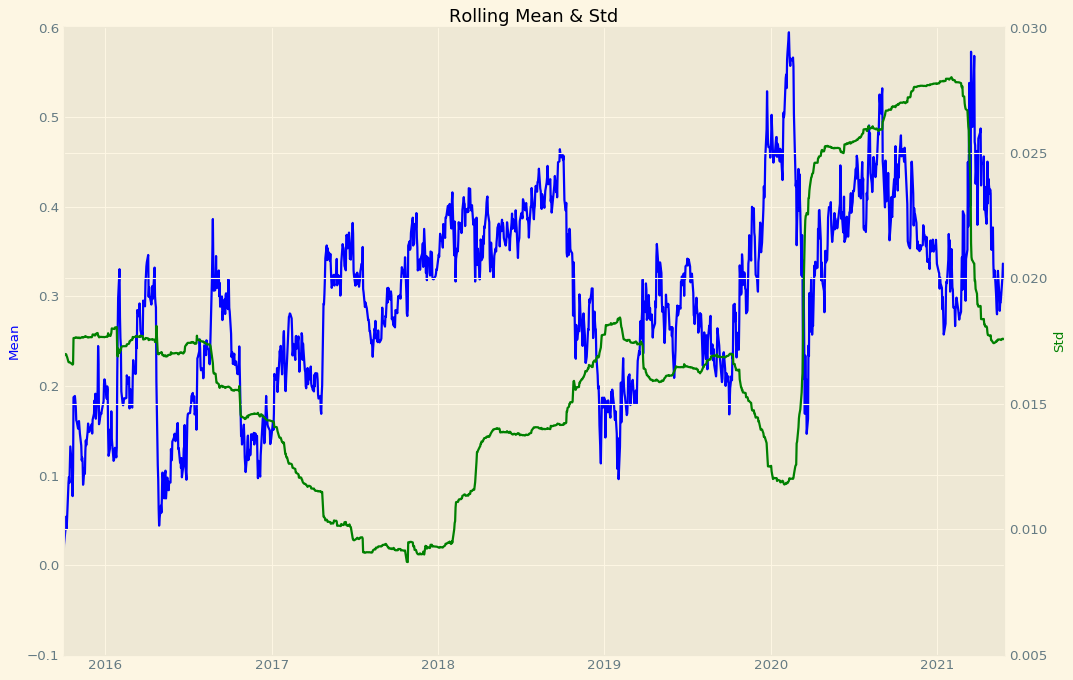

In [112]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,8))

ax1.plot(roll_mean, color='blue', label='Rolling Mean')
ax1.set_ylabel('Mean', color='blue')

ax2 = ax1.twinx()
ax2.plot(roll_std, color='green', label='Rolling Std')
ax2.set_ylabel('Std', color='green')

plt.title('Rolling Mean & Std')
plt.show()


**Grün ist die gleitende Standartabweichung der logarithmischen Gesamtrendite und fungiert als gleitendes Risiko. Der blaue Graph ist der gleitende Mittelwert der logarithmischen Gesamtrendite. VOn 2017 - 2018 ist deutlich zu erkennen, dass die Rendite hoch und das Risiko niedrig ist.**

# Take Home: Be carefull, you´ll always find (sub-) periods with **low returns & high risk** and **high returns & low risk.**

- Analysis Period must be **sufficiently long** to reduce impact of random noise.
- Analysis Period should be **as short as possible** and should only include the **latest trends / regimes.**
- Comonly used reporting period: **3 Years / 36 Months.**

**Another Example: Simple Moving Average (Prices) - SMA**

In [123]:
sma_window=50

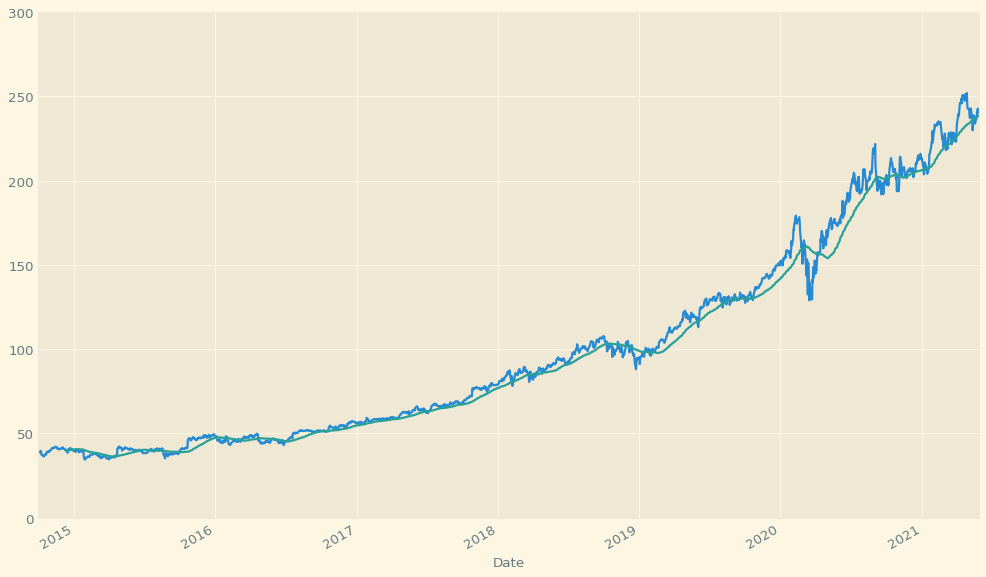

In [125]:
msft.Price.plot(figsize=(12,8)) #blue line
msft.Price.rolling(sma_window).mean().plot() # green line
plt.show()